In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import pandas as pd
import time
from functions import*

In [2]:
# Define an RBF (Gaussian) Kernel
def rbf_kernel(X1, X2, length_scale=0.1, sigma_f=1.0):
    """Computes the RBF kernel matrix."""
    sq_dist = cdist(X1, X2, 'sqeuclidean')
    return sigma_f ** 2 * np.exp(-sq_dist / (2 * length_scale ** 2))

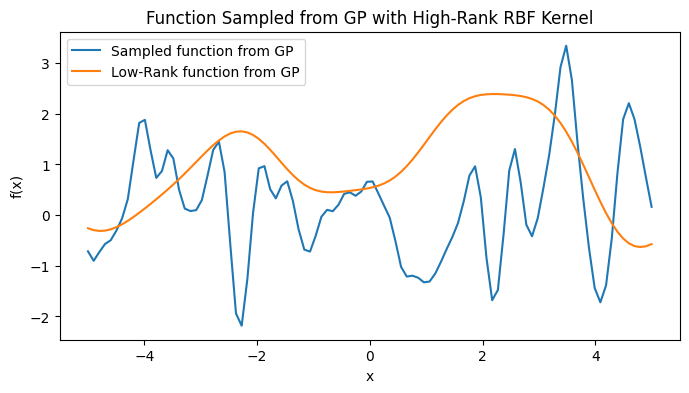

In [3]:
# Generate input points
X = np.linspace(-5, 5, 10**2).reshape(-1, 1)

# Compute kernel matrix (covariance matrix for the GP)
cov = rbf_kernel(X, X, length_scale=0.2)
cov_low_rank = rbf_kernel(X, X, length_scale=1)

# Sample from a Gaussian Process (mean=0, covariance=K)
f_samples = np.random.multivariate_normal(mean=np.zeros(len(X)), cov=cov)
f_samples_low_rank = np.random.multivariate_normal(mean=np.zeros(len(X)), cov=cov_low_rank)

# Plot the sampled function
plt.figure(figsize=(8, 4))
plt.plot(X, f_samples, label="Sampled function from GP")
plt.plot(X, f_samples_low_rank, label="Low-Rank function from GP")
plt.title("Function Sampled from GP with High-Rank RBF Kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

## Online Bandit Comparison

In [4]:
# Online bandit comparison: EpsilonNet+TS vs Zooming vs MetaTS
# Reports both cumulative regret and per-round runtime.

K = 10
T = 500            # downstream bandit horizon
num_test = 100     # test tasks to average over
num_trials = 10    # independent meta-training repetitions
length_scale = 1.0

gp = GPfunctions_noise(K=K, length_scale=length_scale)
D = np.abs(gp.actionspace[:, None] - gp.actionspace[None, :])  # Euclidean distance on action space

results  = {m: np.zeros((num_trials, T)) for m in ['epsilon', 'zooming', 'metats']}
runtimes = {m: np.zeros(num_trials)      for m in ['epsilon', 'zooming', 'metats']}

for trial in range(num_trials):
    # --- Meta-training ---
    meta_f = gp.samples(size=K)
    subset = np.unique(np.argmax(meta_f, axis=1))
    while len(subset) < K:
        extra = gp.samples(size=K - len(subset))
        subset = np.unique(np.append(subset, np.argmax(extra, axis=1)))

    trial_regrets  = {m: [] for m in results}
    trial_runtimes = {m: [] for m in results}

    for _ in range(num_test):
        f = gp.samples(size=1)[0]

        r, rt = online_regret(f, GaussianTS(len(subset), known_variance=1.0),
                              T, action_set=subset, return_time=True)
        trial_regrets['epsilon'].append(r)
        trial_runtimes['epsilon'].append(rt)

        r, rt = online_regret(f, ZoomingBandit(gp.num_points, D, nu=1.0),
                              T, return_time=True)
        trial_regrets['zooming'].append(r)
        trial_runtimes['zooming'].append(rt)

        r, rt = online_regret(f, MetaTS(gp.num_points, meta_f, known_variance=1.0),
                              T, return_time=True)
        trial_regrets['metats'].append(r)
        trial_runtimes['metats'].append(rt)

    for m in results:
        results[m][trial]  = np.mean(trial_regrets[m],  axis=0)
        runtimes[m][trial] = np.mean(trial_runtimes[m])

print('Done.')
for m, label in [('epsilon', 'EpsilonNet'), ('zooming', 'Zooming'), ('metats', 'MetaTS')]:
    print(f'{label:12s}: {runtimes[m].mean()*1e3:.2f} ms ± {runtimes[m].std()*1e3:.2f} ms per task')


Done.
EpsilonNet  : 10.74 ms ± 0.42 ms per task
Zooming     : 150.33 ms ± 2.57 ms per task
MetaTS      : 18.63 ms ± 0.59 ms per task


<>:25: SyntaxWarning: invalid escape sequence '\_'
<>:25: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_63595/3305284400.py:25: SyntaxWarning: invalid escape sequence '\_'
  ax1.set_title(f'Online Regret (length\_scale={length_scale}, K={K})')


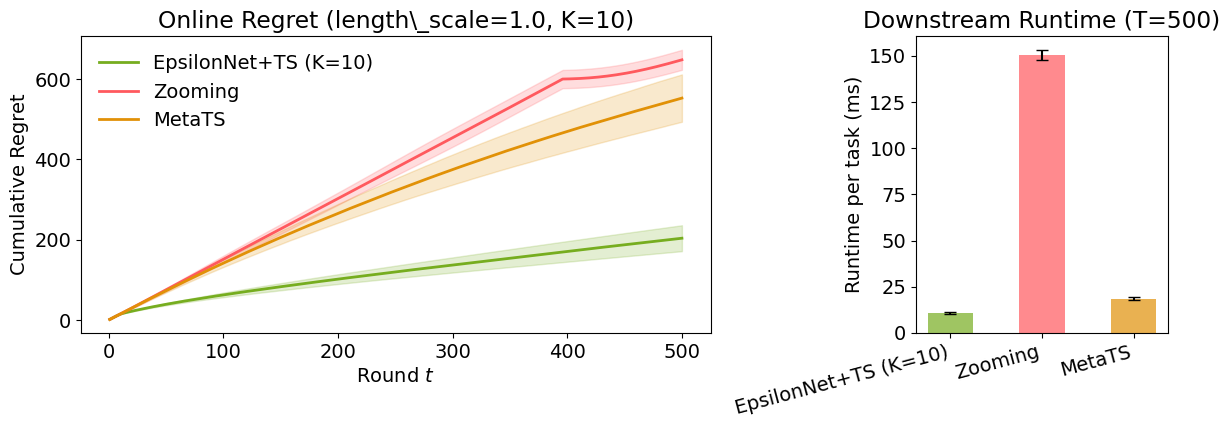

In [5]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 14})

methods = ['epsilon', 'zooming', 'metats']
labels  = {
    'epsilon': f'EpsilonNet+TS (K={K})',
    'zooming': 'Zooming',
    'metats':  'MetaTS',
}
colors = {'epsilon': '#76ad1f', 'zooming': '#ff595e', 'metats': '#E19107FF'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5),
                               gridspec_kw={'width_ratios': [2.5, 1]})

# --- Left: cumulative regret curves ---
for m in methods:
    mean = results[m].mean(axis=0)
    std  = results[m].std(axis=0)
    ax1.plot(range(1, T + 1), mean, label=labels[m], color=colors[m], linewidth=2)
    ax1.fill_between(range(1, T + 1), mean - std, mean + std,
                     alpha=0.2, color=colors[m])
ax1.set_xlabel('Round $t$')
ax1.set_ylabel('Cumulative Regret')
ax1.set_title(f'Online Regret (length\_scale={length_scale}, K={K})')
ax1.legend(framealpha=0)

# --- Right: runtime bar chart (ms per downstream task) ---
x = np.arange(len(methods))
means_rt = np.array([runtimes[m].mean() * 1e3 for m in methods])
stds_rt  = np.array([runtimes[m].std()  * 1e3 for m in methods])
ax2.bar(x, means_rt, yerr=stds_rt, capsize=4,
        color=[colors[m] for m in methods], alpha=0.7, width=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels([labels[m] for m in methods], rotation=15, ha='right')
ax2.set_ylabel('Runtime per task (ms)')
ax2.set_title(f'Downstream Runtime (T={T})')

plt.tight_layout()
plt.savefig('RKHS_online_regret.pdf', format='pdf', bbox_inches='tight',
            pad_inches=0, transparent=True)
plt.show()
